<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Algoritmos_Basados_en_Grafos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Algoritmos basados en grafos: BFS, DFS y Backtracking


## 🎯 Objetivos

Este notebook tiene como objetivo explicar y comparar tres enfoques fundamentales:

1. **BFS (Breadth-First Search)**: búsqueda por anchura.
2. **DFS (Depth-First Search)**: búsqueda por profundidad.
3. **Backtracking**: construcción de soluciones mediante exploración, validación y poda.


## 🧠 La idea central de la clase es distinguir dos tipos de algoritmos basados en grafos:

- Algoritmos que **buscan soluciones dentro de un grafo ya definido**, como BFS y DFS.
- Algoritmos que **construyen un grafo de búsqueda a partir de opciones y restricciones**, como Backtracking.


## 1. Idea general: ¿qué significa buscar en un grafo?

Un grafo se define como:

$$G = (V, E)$$

Donde:

- $V$ es el conjunto de vértices o nodos.
- $E$ es el conjunto de aristas o conexiones.

En algoritmos como **BFS** y **DFS**, el grafo ya existe. Por ejemplo, un mapa de ciudades conectadas por carreteras.

En **Backtracking**, muchas veces el grafo no está dado de forma explícita. El algoritmo lo va construyendo conforme toma decisiones. Cada decisión genera un nuevo estado y, por lo tanto, una nueva rama dentro del árbol de búsqueda.


## 2. Mapa de Rumania como grafo no ponderado

Usaremos el mapa clásico de Rumania para ejemplificar BFS y DFS. En este caso, cada ciudad es un nodo y cada conexión representa una carretera.

> Nota: Para que los recorridos sean reproducibles, las listas de vecinos se ordenan alfabéticamente dentro de las funciones.


In [ ]:
graph = {
    'Arad': {'Zerind', 'Sibiu', 'Timisoara'},
    'Zerind': {'Oradea', 'Arad'},
    'Oradea': {'Zerind', 'Sibiu'},
    'Sibiu': {'Arad', 'Oradea', 'Fagaras', 'Rimnicu Vilcea'},
    'Timisoara': {'Arad', 'Lugoj'},
    'Lugoj': {'Timisoara', 'Mehadia'},
    'Mehadia': {'Lugoj', 'Drobeta'},
    'Drobeta': {'Mehadia', 'Craiova'},
    'Craiova': {'Drobeta', 'Rimnicu Vilcea', 'Pitesti'},
    'Rimnicu Vilcea': {'Sibiu', 'Craiova', 'Pitesti'},
    'Fagaras': {'Sibiu', 'Bucharest'},
    'Pitesti': {'Rimnicu Vilcea', 'Craiova', 'Bucharest'},
    'Bucharest': {'Fagaras', 'Pitesti'}
}

for city, neighbors in graph.items():
    print(f"{city}: {sorted(neighbors)}")

Arad: ['Sibiu', 'Timisoara', 'Zerind']
Zerind: ['Arad', 'Oradea']
Oradea: ['Sibiu', 'Zerind']
Sibiu: ['Arad', 'Fagaras', 'Oradea', 'Rimnicu Vilcea']
Timisoara: ['Arad', 'Lugoj']
Lugoj: ['Mehadia', 'Timisoara']
Mehadia: ['Drobeta', 'Lugoj']
Drobeta: ['Craiova', 'Mehadia']
Craiova: ['Drobeta', 'Pitesti', 'Rimnicu Vilcea']
Rimnicu Vilcea: ['Craiova', 'Pitesti', 'Sibiu']
Fagaras: ['Bucharest', 'Sibiu']
Pitesti: ['Bucharest', 'Craiova', 'Rimnicu Vilcea']
Bucharest: ['Fagaras', 'Pitesti']


## 3. BFS: Búsqueda por anchura

**BFS** explora el grafo por niveles. Primero visita los vecinos inmediatos, después los vecinos de esos vecinos, y así sucesivamente.

Utiliza una **cola** como estructura auxiliar.

### Aplicaciones típicas

- Encontrar el camino más corto en grafos no ponderados.
- Analizar niveles de conexión.
- Recorrer redes sociales o mapas sin pesos.

### Complejidad

Si el grafo se representa con listas de adyacencia:

$$O(V + E)$$

Donde $V$ es el número de vértices y $E$ el número de aristas.


In [ ]:
from collections import deque

def bfs(graph: dict[str, set[str]], start: str) -> list[str]:
    visited = set()
    order = []
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.add(node)
            order.append(node)

            for neighbor in sorted(graph[node]):
                if neighbor not in visited:
                    queue.append(neighbor)

    return order

bfs_order = bfs(graph, 'Arad')
print('Recorrido BFS desde Arad:')
print(bfs_order)

Recorrido BFS desde Arad:
['Arad', 'Sibiu', 'Timisoara', 'Zerind', 'Fagaras', 'Oradea', 'Rimnicu Vilcea', 'Lugoj', 'Bucharest', 'Craiova', 'Pitesti', 'Mehadia', 'Drobeta']


## 4. BFS para encontrar camino entre dos ciudades

Una ventaja importante de BFS es que puede encontrar el camino con menor número de aristas en grafos no ponderados.


In [ ]:
def bfs_path(graph: dict[str, set[str]], start: str, goal: str) -> list[str] | None:
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in sorted(graph[node]):
                if neighbor not in visited:
                    queue.append((neighbor, path + [neighbor]))

    return None

path = bfs_path(graph, 'Arad', 'Bucharest')
print('Camino encontrado por BFS de Arad a Bucharest:')
print(path)
print('Número de aristas:', len(path) - 1 if path else None)

Camino encontrado por BFS de Arad a Bucharest:
['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Número de aristas: 3


## 5. DFS: Búsqueda por profundidad

**DFS** explora una rama hasta donde sea posible antes de regresar y probar otra rama.

Puede implementarse con recursión o con una pila explícita.

### Aplicaciones típicas

- Recorrer grafos.
- Detectar ciclos.
- Explorar componentes conectados.
- Resolver problemas donde interesa profundizar primero en una posibilidad.

### Complejidad

Con listas de adyacencia:

$$O(V + E)$$


In [ ]:
def dfs_recursive(graph: dict[str, set[str]], start: str, goal: str) -> list[str]:
    visited = set()
    path = []

    def visit(node: str) -> bool:
        visited.add(node)
        path.append(node)

        if node == goal:
            return True

        for neighbor in sorted(graph[node]):
            if neighbor not in visited:
                if visit(neighbor):
                    return True

        # Backtrack del camino
        path.pop()
        return False

    visit(start)
    return path


def dfs_iterative(graph: dict[str, set[str]], start: str, goal: str) -> list[str]:
    stack = [(start, [start])]
    visited = set()

    while stack:
        node, path = stack.pop()

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in reversed(sorted(graph[node])):
                if neighbor not in visited:
                    stack.append((neighbor, path + [neighbor]))

    return []

print('DFS recursivo de Arad a Bucharest:')
print(dfs_recursive(graph, 'Arad', 'Bucharest'))

print('DFS iterativo de Arad a Bucharest:')
print(dfs_iterative(graph, 'Arad', 'Bucharest'))

DFS recursivo de Arad a Bucharest:
['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
DFS iterativo de Arad a Bucharest:
['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


## 6. Comparación conceptual: BFS vs DFS

| Aspecto | BFS | DFS |
|---|---|---|
| Estrategia | Explora por niveles | Explora por profundidad |
| Estructura auxiliar | Cola | Pila o recursión |
| Camino más corto en grafo no ponderado | Sí | No necesariamente |
| Complejidad temporal | $O(V + E)$ | $O(V + E)$ |
| Uso común | Distancias mínimas sin pesos | Exploración, ciclos, componentes |

Aunque ambos recorren grafos, el orden de exploración cambia por completo.


## 7. Backtracking: construir un grafo de búsqueda

A diferencia de BFS y DFS, en Backtracking normalmente no tenemos un grafo explícito desde el inicio.

El algoritmo construye un **árbol de decisiones**:

- Cada nodo representa una solución parcial.
- Cada arista representa una decisión.
- Cada rama puede descartarse si viola alguna restricción.

Backtracking puede entenderse como:

> DFS + validación + poda

Es decir, explora en profundidad, pero no explora ramas que ya sabemos que no pueden producir una solución válida.


## 8. Problema de las N-Reinas

El problema consiste en colocar $n$ reinas en un tablero de $n 	imes n$ de forma que ninguna reina ataque a otra.

Dos reinas se atacan si están en:

- La misma fila.
- La misma columna.
- La misma diagonal.

En esta implementación, el estado se representa como una lista:

```python
estado[columna] = fila
```

Es decir, el índice representa la columna y el valor representa la fila donde se colocó la reina.


In [ ]:
def n_queens(n: int, verbose: bool = False) -> list[list[int]]:
    estado = [-1] * n
    soluciones = []
    ops = list(range(n))

    def es_valida(fila: int, columna: int, verbose: bool = False) -> bool:
        for i in range(columna):
            if estado[i] == fila or abs(estado[i] - fila) == abs(i - columna):
                if verbose:
                    print(
                        f"Fila {fila} no es válida para columna {columna} "
                        f"debido a la reina en columna {i}, fila {estado[i]}"
                    )
                return False
        return True

    def backtracking(columna: int, opciones: list[int], verbose: bool = False):
        if verbose:
            print(f"Columna: {columna}, Opciones: {opciones}, Estado: {estado}")

        if len(opciones) == 0:
            if verbose:
                print(f"Solución encontrada: {estado}")
            soluciones.append(estado.copy())
            return

        for fila in opciones:
            if es_valida(fila, columna, verbose):
                estado[columna] = fila
                temp = opciones.copy()
                temp.remove(fila)
                backtracking(columna + 1, temp, verbose)
                estado[columna] = -1

    backtracking(0, ops, verbose)
    return soluciones

soluciones_4 = n_queens(4)
print(f'Total de soluciones para 4 reinas: {len(soluciones_4)}')
print(soluciones_4)

Total de soluciones para 4 reinas: 2
[[1, 3, 0, 2], [2, 0, 3, 1]]


## 9. Verificación de diagonales

Si una reina está en la posición:

$$(i, estado[i])$$

y queremos colocar otra en:

$$(columna, fila)$$

entonces ambas están en la misma diagonal cuando la distancia horizontal y vertical es la misma:

$$|i - columna| = |estado[i] - fila|$$

Por eso se usa la condición:

```python
abs(estado[i] - fila) == abs(i - columna)
```


In [ ]:
def print_board(solution: list[int]) -> None:
    n = len(solution)
    for row in range(n):
        line = []
        for col in range(n):
            if solution[col] == row:
                line.append('Q')
            else:
                line.append('.')
        print(' '.join(line))

print('Primera solución para 4 reinas:')
print_board(soluciones_4[0])

Primera solución para 4 reinas:
. . Q .
Q . . .
. . . Q
. Q . .


## 10. Similitudes y diferencias entre DFS, BFS y Backtracking

| Aspecto | BFS | DFS | Backtracking |
|---|---|---|---|
| Tipo | Algoritmo de recorrido | Algoritmo de recorrido | Técnica de diseño |
| Grafo | Explícito | Explícito | Implícito o construido |
| Estructura | Cola | Pila/recursión | Recursión + estado |
| Poda | No necesariamente | No necesariamente | Sí |
| Objetivo | Explorar por niveles | Explorar profundamente | Construir soluciones válidas |
| Aplicaciones | Rutas sin pesos | Ciclos, componentes, exploración | Sudoku, N-Reinas, combinaciones |

La idea clave es:

> DFS y BFS recorren un grafo existente. Backtracking genera un árbol de búsqueda con base en decisiones, opciones y restricciones.


# Laboratorio 1: Rendimiento de BFS

Para analizar el comportamiento temporal de BFS, generaremos grafos en forma de camino.

Un grafo camino de tamaño $n$ tiene:

- $V = n$ vértices.
- $E = n - 1$ aristas.

Por lo tanto, esperamos un crecimiento cercano a:

$$O(V + E) pprox O(n)$$


n=  100 | tiempo promedio BFS=0.00003146 s
n=  500 | tiempo promedio BFS=0.00015584 s
n= 1000 | tiempo promedio BFS=0.00029558 s
n= 2000 | tiempo promedio BFS=0.00067865 s
n= 4000 | tiempo promedio BFS=0.00127298 s
n= 8000 | tiempo promedio BFS=0.00408012 s


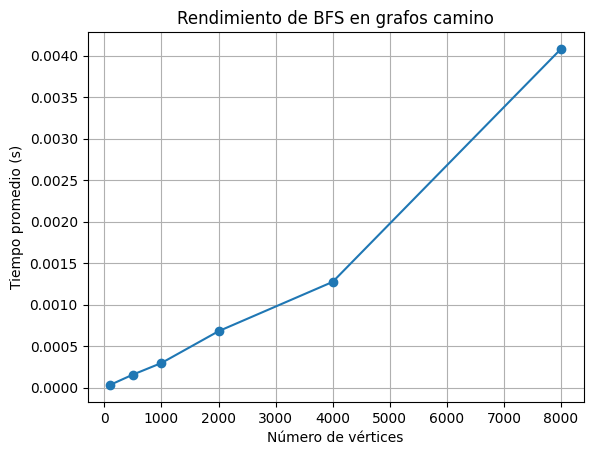

In [ ]:
import time
import matplotlib.pyplot as plt

def make_path_graph(n: int) -> dict[int, set[int]]:
    g = {i: set() for i in range(n)}
    for i in range(n - 1):
        g[i].add(i + 1)
        g[i + 1].add(i)
    return g


def bfs_numeric(graph: dict[int, set[int]], start: int) -> list[int]:
    visited = set()
    order = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            order.append(node)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    queue.append(neighbor)
    return order


def measure_time(func, *args, repetitions: int = 5) -> float:
    times = []
    for _ in range(repetitions):
        start = time.perf_counter()
        func(*args)
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)

sizes = [100, 500, 1000, 2000, 4000, 8000]
bfs_times = []

for n in sizes:
    g = make_path_graph(n)
    t = measure_time(bfs_numeric, g, 0)
    bfs_times.append(t)
    print(f'n={n:5d} | tiempo promedio BFS={t:.8f} s')

plt.figure()
plt.plot(sizes, bfs_times, marker='o')
plt.xlabel('Número de vértices')
plt.ylabel('Tiempo promedio (s)')
plt.title('Rendimiento de BFS en grafos camino')
plt.grid(True)
plt.show()

# Laboratorio 2: Rendimiento de DFS

DFS también tiene complejidad:

$$O(V + E)$$

Para evitar problemas con el límite de recursión de Python, en esta prueba se utiliza DFS iterativo.


n=  100 | tiempo promedio DFS=0.00005694 s
n=  500 | tiempo promedio DFS=0.00032926 s
n= 1000 | tiempo promedio DFS=0.00033390 s
n= 2000 | tiempo promedio DFS=0.00074615 s
n= 4000 | tiempo promedio DFS=0.00146218 s
n= 8000 | tiempo promedio DFS=0.00281569 s


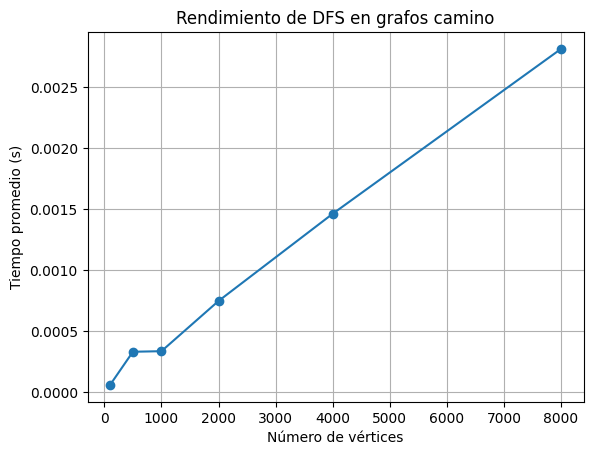

In [ ]:
def dfs_numeric_iterative(graph: dict[int, set[int]], start: int) -> list[int]:
    visited = set()
    order = []
    stack = [start]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            order.append(node)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    stack.append(neighbor)
    return order

dfs_times = []

for n in sizes:
    g = make_path_graph(n)
    t = measure_time(dfs_numeric_iterative, g, 0)
    dfs_times.append(t)
    print(f'n={n:5d} | tiempo promedio DFS={t:.8f} s')

plt.figure()
plt.plot(sizes, dfs_times, marker='o')
plt.xlabel('Número de vértices')
plt.ylabel('Tiempo promedio (s)')
plt.title('Rendimiento de DFS en grafos camino')
plt.grid(True)
plt.show()

## Comparación experimental BFS vs DFS

Ambos algoritmos recorren vértices y aristas. Por ello, en grafos, ambos deberían presentar una tendencia aproximadamente lineal.


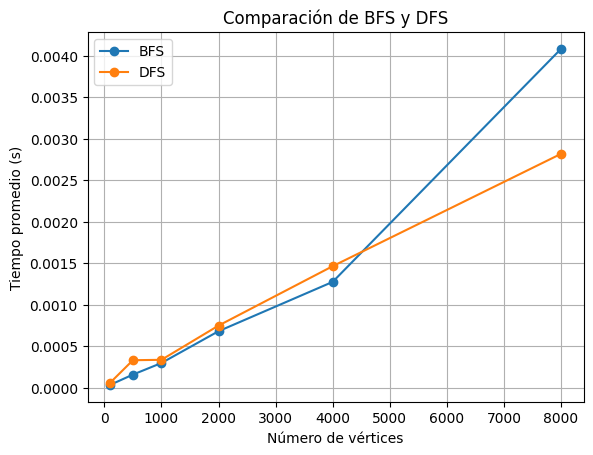

In [ ]:
plt.figure()
plt.plot(sizes, bfs_times, marker='o', label='BFS')
plt.plot(sizes, dfs_times, marker='o', label='DFS')
plt.xlabel('Número de vértices')
plt.ylabel('Tiempo promedio (s)')
plt.title('Comparación de BFS y DFS')
plt.legend()
plt.grid(True)
plt.show()

# Laboratorio 3: Rendimiento de Backtracking con N-Reinas

Backtracking no tiene una complejidad lineal. En el caso de N-Reinas, el espacio de búsqueda está relacionado con las permutaciones posibles de filas para columnas.

Una cota superior razonable para esta versión es:

$$O(n!)$$

Esto ocurre porque se intenta colocar una reina por columna y se evita repetir filas. Aun así, la poda por diagonales reduce una gran cantidad de ramas inválidas.

En este laboratorio se mide el tiempo para distintos valores de $n$.


n= 4 | soluciones=    2 | tiempo=0.00005857 s
n= 5 | soluciones=   10 | tiempo=0.00009867 s
n= 6 | soluciones=    4 | tiempo=0.00036307 s
n= 7 | soluciones=   40 | tiempo=0.00427021 s
n= 8 | soluciones=   92 | tiempo=0.00442772 s
n= 9 | soluciones=  352 | tiempo=0.01785869 s
n=10 | soluciones=  724 | tiempo=0.09045118 s


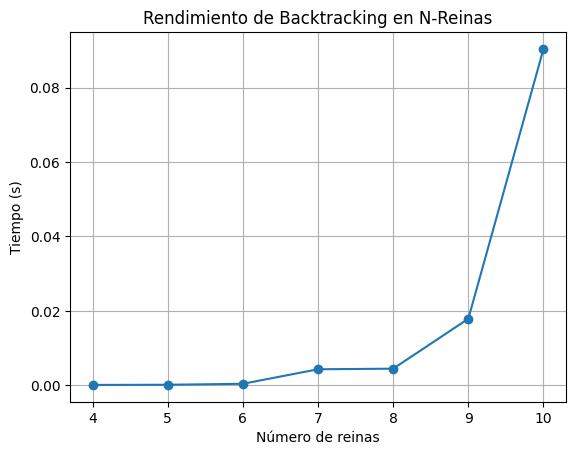

In [ ]:
queen_sizes = [4, 5, 6, 7, 8, 9, 10]
queen_times = []
queen_counts = []

for n in queen_sizes:
    start = time.perf_counter()
    solutions = n_queens(n)
    end = time.perf_counter()

    elapsed = end - start
    queen_times.append(elapsed)
    queen_counts.append(len(solutions))

    print(f'n={n:2d} | soluciones={len(solutions):5d} | tiempo={elapsed:.8f} s')

plt.figure()
plt.plot(queen_sizes, queen_times, marker='o')
plt.xlabel('Número de reinas')
plt.ylabel('Tiempo (s)')
plt.title('Rendimiento de Backtracking en N-Reinas')
plt.grid(True)
plt.show()

## Comparación con escala logarítmica

Cuando el crecimiento es muy rápido, una escala lineal puede ocultar diferencias importantes. Por eso también se puede graficar el tiempo en escala logarítmica.


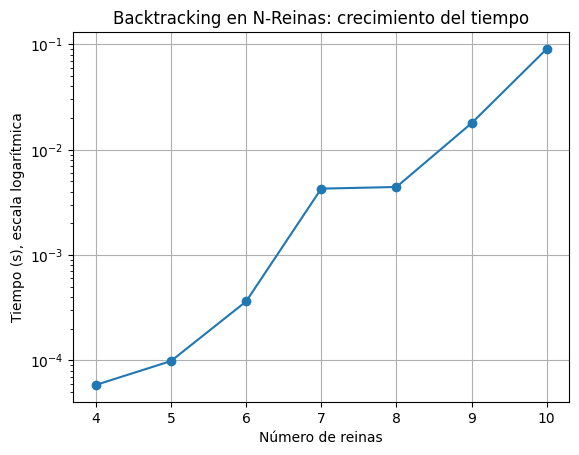

In [ ]:
plt.figure()
plt.semilogy(queen_sizes, queen_times, marker='o')
plt.xlabel('Número de reinas')
plt.ylabel('Tiempo (s), escala logarítmica')
plt.title('Backtracking en N-Reinas: crecimiento del tiempo')
plt.grid(True)
plt.show()

# Laboratorio 4: Efecto de la poda en Backtracking

Para observar la importancia de la poda, contaremos cuántos estados explora el algoritmo.

La poda evita seguir explorando ramas donde una solución ya es imposible.


n= 4 | soluciones=    2 | estados visitados=      17
n= 5 | soluciones=   10 | estados visitados=      54
n= 6 | soluciones=    4 | estados visitados=     153
n= 7 | soluciones=   40 | estados visitados=     552
n= 8 | soluciones=   92 | estados visitados=    2057
n= 9 | soluciones=  352 | estados visitados=    8394
n=10 | soluciones=  724 | estados visitados=   35539


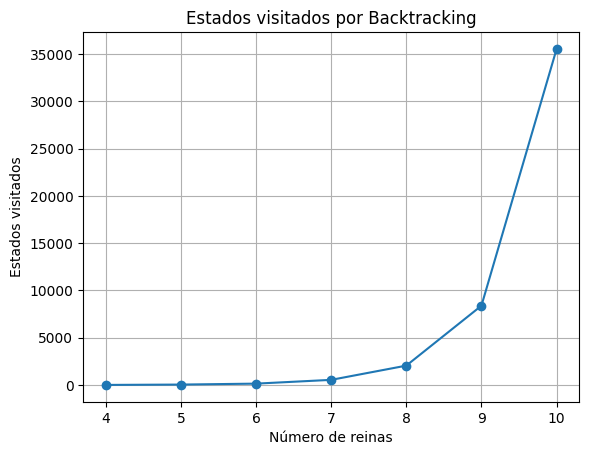

In [ ]:
def n_queens_count_states(n: int) -> tuple[int, int]:
    estado = [-1] * n
    soluciones = 0
    estados_visitados = 0
    ops = list(range(n))

    def es_valida(fila: int, columna: int) -> bool:
        for i in range(columna):
            if estado[i] == fila or abs(estado[i] - fila) == abs(i - columna):
                return False
        return True

    def backtracking(columna: int, opciones: list[int]):
        nonlocal soluciones, estados_visitados
        estados_visitados += 1

        if len(opciones) == 0:
            soluciones += 1
            return

        for fila in opciones:
            if es_valida(fila, columna):
                estado[columna] = fila
                temp = opciones.copy()
                temp.remove(fila)
                backtracking(columna + 1, temp)
                estado[columna] = -1

    backtracking(0, ops)
    return soluciones, estados_visitados

state_counts = []

for n in queen_sizes:
    solutions, states = n_queens_count_states(n)
    state_counts.append(states)
    print(f'n={n:2d} | soluciones={solutions:5d} | estados visitados={states:8d}')

plt.figure()
plt.plot(queen_sizes, state_counts, marker='o')
plt.xlabel('Número de reinas')
plt.ylabel('Estados visitados')
plt.title('Estados visitados por Backtracking')
plt.grid(True)
plt.show()

## Actividad de análisis para estudiantes

Responde las siguientes preguntas en tu reporte:

1. ¿Por qué BFS encuentra el camino con menor número de aristas en un grafo no ponderado?
2. ¿Por qué DFS no garantiza encontrar el camino más corto?
3. ¿Qué diferencia existe entre recorrer un grafo explícito y construir un árbol de búsqueda?
4. ¿Qué representa cada nodo en el árbol de búsqueda del problema de N-Reinas?
5. ¿Qué pasaría si eliminamos la función `es_valida` del algoritmo de N-Reinas?
6. ¿Por qué la poda reduce el tiempo de ejecución, pero no convierte necesariamente el problema en uno polinomial?


# Conclusiones

- **BFS** y **DFS** son algoritmos de recorrido sobre grafos ya definidos.
- **BFS** explora por niveles y es adecuado para encontrar caminos mínimos en grafos no ponderados.
- **DFS** explora profundamente y es útil para análisis estructural del grafo.
- **Backtracking** utiliza una lógica similar a DFS, pero construye soluciones parciales y descarta ramas inválidas mediante poda.
- En términos de complejidad, BFS y DFS tienen crecimiento $O(V + E)$, mientras que Backtracking suele enfrentar espacios de búsqueda exponenciales o factoriales.

La diferencia didáctica más importante es:

> BFS y DFS buscan dentro de un grafo. Backtracking construye el grafo de búsqueda mientras intenta resolver el problema.
